Convolutional Neural Network for Automatic Handwritten Digit Recognition

 1. Import Required Libraries


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , accuracy_score
import seaborn as sns


print("import success")


import success


2. Load Dataset


In [10]:
train_data = pd.read_csv("./data/mnist_train.csv")
test_data = pd.read_csv("./data/mnist_test.csv")

train_data.head()

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


3. Split Labels and Pixels

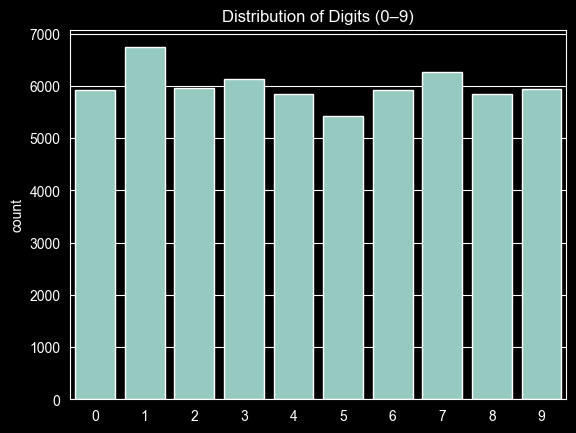

In [11]:
X_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values


sns.countplot(x=y_train)
plt.title("Distribution of Digits (0–9)")
plt.show()

4. Pixel Intensity Histogram

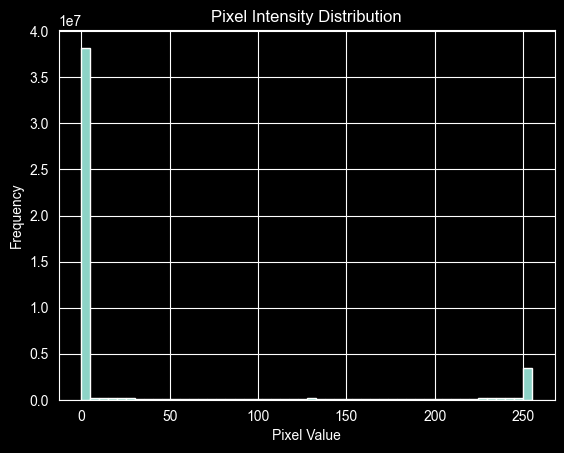

In [12]:
plt.hist(X_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

5. Sample images

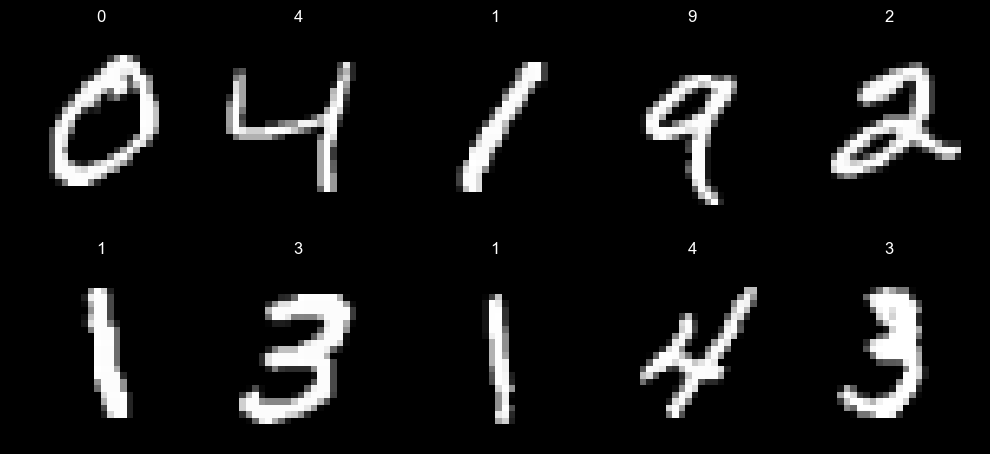

In [13]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"{y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

6. Normalize Pixel Values

In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0


7. Reshape into 28x28 Images

In [15]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

 8. One-Hot Encode Labels

In [16]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

9. Build CNN Model

In [17]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


C:\Users\User\Workspace\PycharmProjects\digician\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10. Model Summary

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

11. Compile Model

In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

12. Train Model

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9354 - loss: 0.2098 - val_accuracy: 0.9840 - val_loss: 0.0539
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9801 - loss: 0.0649 - val_accuracy: 0.9850 - val_loss: 0.0435
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9859 - loss: 0.0463 - val_accuracy: 0.9878 - val_loss: 0.0407
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9885 - loss: 0.0371 - val_accuracy: 0.9913 - val_loss: 0.0342
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9910 - loss: 0.0294 - val_accuracy: 0.9917 - val_loss: 0.0324


13. Accuracy Graph

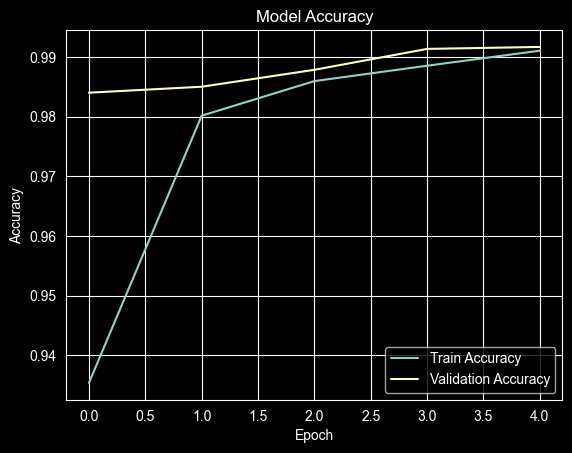

In [21]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

14. Evaluate Model

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9921 - loss: 0.0271
Test Accuracy: 0.9920992255210876


15. Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


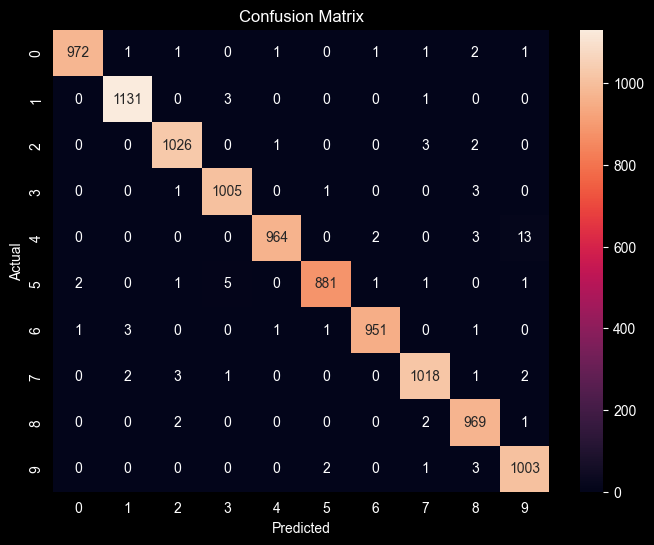

In [23]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
acc = accuracy_score(y_true, y_pred_classes)
print("Accuracy Score:", acc)

Accuracy Score: 0.9920992099209921


16. Predict Example Digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted Digit: 2


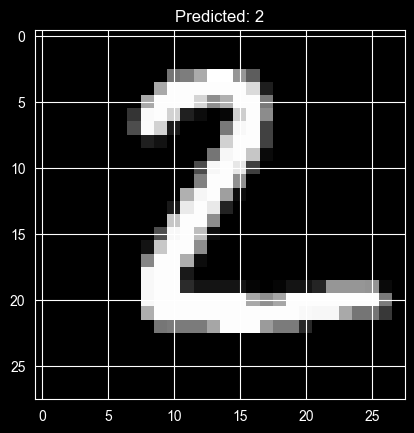

In [25]:
sample = X_test[0].reshape(1,28,28,1)
prediction = model.predict(sample)

predicted_digit = np.argmax(prediction)
print("Predicted Digit:", predicted_digit)

# Show image
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.show()


In [51]:
model.save("../artifacts/mnist_cnn.keras")

In [38]:
from PIL import Image
import numpy as np

def preprocess_image(path):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28))
    img = np.array(img)

    img = img / 255.0
    img = img.reshape(1, 28, 28, 1)
    return img

In [45]:
def predict(model, img):
    # img is already preprocessed except inversion (shape 1,28,28,1, normalized)

    # original
    pred1 = model.predict(img, verbose=0)
    conf1 = np.max(pred1)

    # inverted
    img_inv = 1.0 - img  # since already normalized
    pred2 = model.predict(img_inv, verbose=0)
    conf2 = np.max(pred2)

    if conf2 > conf1:
        return np.argmax(pred2), float(conf2), True
    else:
        return np.argmax(pred1), float(conf1), False

In [49]:
img = preprocess_image("digit.png")  # no inversion inside this now

digit, conf, inverted = predict(model, img)

print("Predicted:", digit)
print("Confidence:", conf)
print("Used inverted:", inverted)

Predicted: 4
Confidence: 0.8438489437103271
Used inverted: True
